In [1]:
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(ggplot2)
library(patchwork)
library(hdf5r)
library(future)
library(RColorBrewer)
library(dplyr)
library(Matrix)
library(BSgenome.Hsapiens.UCSC.hg38)
library(glue)
library(harmony)
library(matrixStats)
library(scales)
library(biomaRt)
library(curl)
library(goseq)
library(httr)
library(Scillus)
library(TFBSTools)
library(JASPAR2020)
library(ggridges)
library(ggrepel)
library(ggsignif)
library(qusage)
library(tidyverse)
httr::set_config(config(ssl_verifypeer = 0L))
set.seed(1234)
setwd("/home/jupyter/scATAC_analysis/edit/snatac-rcc-manuscript")
source("scripts/functions.r")


Attaching SeuratObject

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: ensembldb

Loading required packag

# Figure 2A: UMAP of putative tumor cells from all samples

Read in seurat object with RCC tumor cells

In [2]:
tumor <- readRDS("processed_data/rcc_tumor_cells_seurat.rds")

Define tumor annotation order so that we can assign a color to a specific annotation

In [3]:
# order
levels <- unique(tumor$annotation)[-2]
tumor$annotation <- factor(tumor$annotation, levels = c("Excluded", levels))

# colors
excluded <- alpha(c("#E8E9EB"), 0.3)
sample_cols <- colorRampPalette(brewer.pal(8, "Set2"))(8)
p1 <- sample_cols[3:7]
sample_cols <- c(p1, sample_cols[2])


Plot UMAP

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



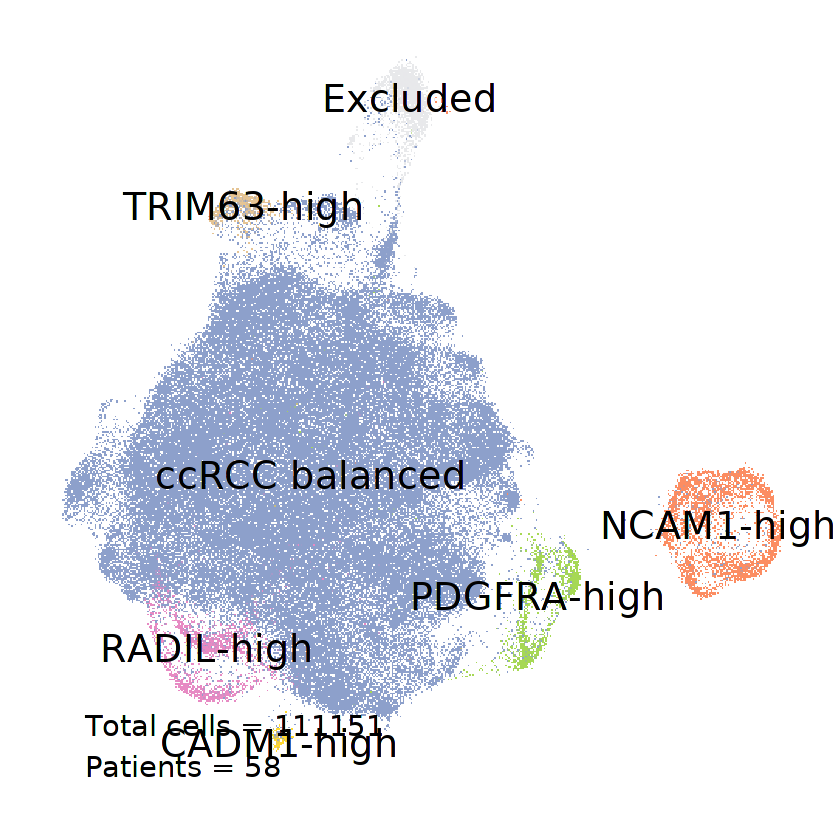

In [4]:
# Counts
cells <- tumor@meta.data %>%
  filter(annotation != "Excluded") %>%
  nrow()

num_pts <- tumor@meta.data %>%
  filter(annotation != "Excluded") %>%
  pull(participant) %>%
  unique() %>%
  length()

# Create plot
DimPlot(
  tumor,
  label = TRUE,
  label.size = 8,
  group.by = "annotation",
  cols = c(excluded, sample_cols),
  raster = TRUE,
  reduction = "harmony_UMAP",
  shuffle = TRUE
) +
  theme(
    plot.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    axis.line = element_blank(),
    axis.title = element_blank()
  ) +
  NoLegend() +
  annotate(
    "text",
    x = min(Embeddings(tumor, "harmony_UMAP")[, 1]) + 0.5,
    y = min(Embeddings(tumor, "harmony_UMAP")[, 2]) - 0.5,
    label = glue("Total cells = {cells}\nPatients = {num_pts}"),
    hjust = 0,
    vjust = 0,
    size = 6
  ) +
  coord_cartesian(clip = "off")


# Figure 2B: Heatmap of gene activity scores across RCC tumor cell states

Load in differential gene accessibility betwen each RCC tumor cluster and all other RCC tumor clusters. Results in Supp Table 2, sheet A. 

In [5]:
# Read in pre-computed differential gene activity results
differential_geneactivity <- readRDS('processed_data/RCC_tumor_DAGs.rds')

# Filter to cells that DAG was computed on
tumor_filtered <- subset(tumor, subset = annotation %in% setdiff(unique(tumor$annotation), c("Excluded")))


Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from harmony_umap_ to harmonyumap_"


In [6]:
# Set order of annotation for plotting
tumor_filtered$annotation <- factor(tumor_filtered$annotation, levels = levels)
DefaultAssay(tumor_filtered) <- "RNA"
Idents(tumor_filtered) <- "annotation"

# Select top 8 differentially accessible genes per annotation
differential_geneactivity %>%
    group_by(cluster) %>%
    top_n(n = 8, wt = avg_log2FC) -> top8

# Scale gene activity assay for plotting
tumor_filtered <- ScaleData(tumor_filtered, assay = "RNA")


Centering and scaling data matrix



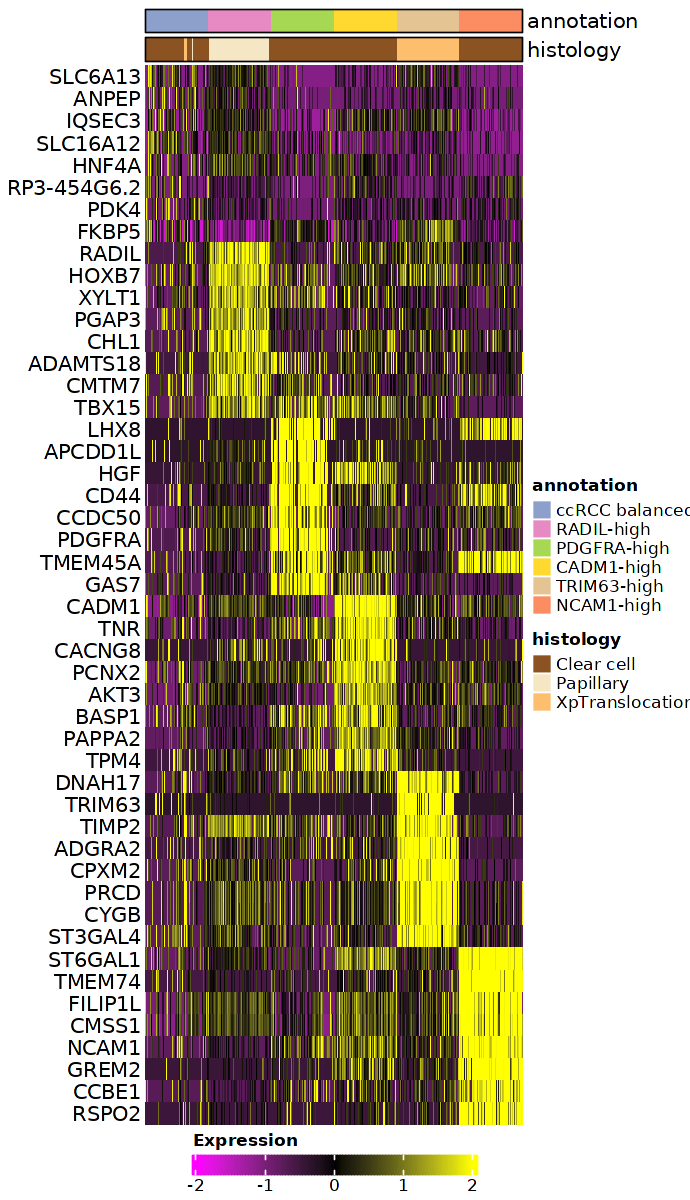

: 

In [ ]:
# Plot heatmap with both tumor annotation and histology bars
options(repr.plot.width = 5.75, repr.plot.height = 10)
histology_colors <- c("#8c5322", "#f5e7c3", "#fdbf6e")
plot_heatmap(subset(tumor_filtered, downsample = 100),
    markers = top8$gene, anno_var = c("annotation", "histology"),
    anno_colors = list(sample_cols, histology_colors), sort_var = c("annotation"), hm_colors = c("magenta", "black", "yellow")
)

# Figure 2C: UMAP of ccRCC tumor cells

In [2]:
ccrcc <- readRDS("processed_data/ccrcc_balanced_seurat.rds")


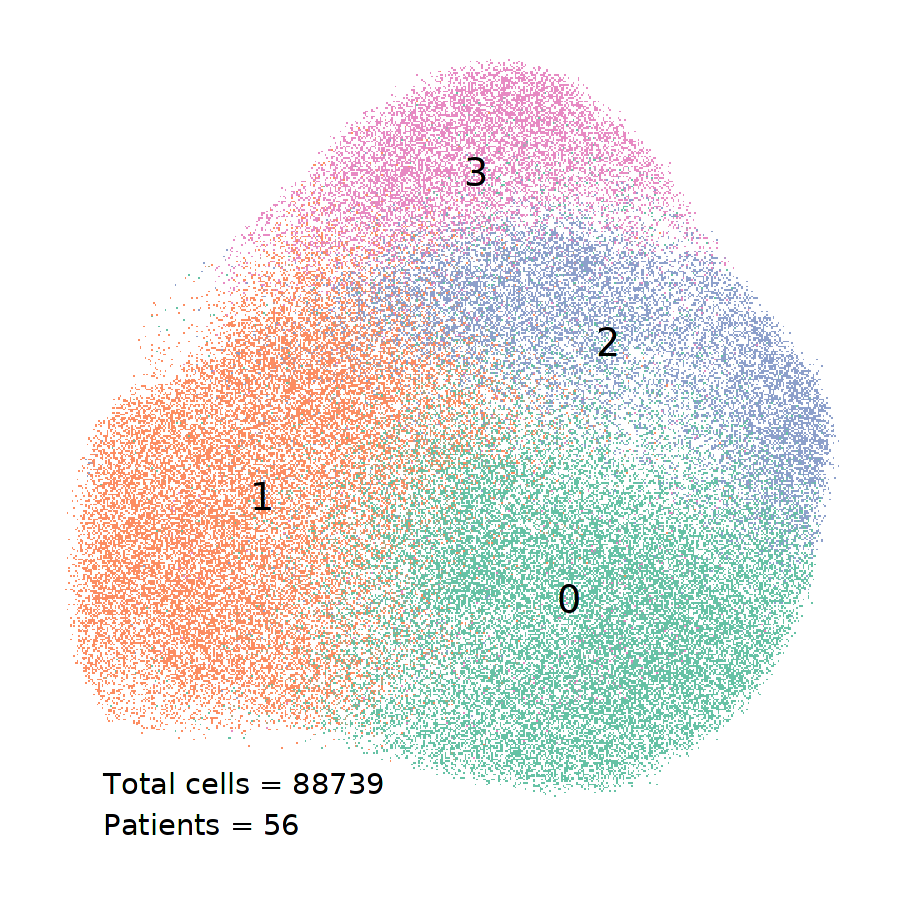

In [4]:
# Counts
cells <- ccrcc@meta.data %>%
  nrow()

num_pts <- ccrcc@meta.data %>%
  pull(participant) %>%
  unique() %>%
  length()

tumor_cols <- colorRampPalette(brewer.pal(4, "Set2"))(4)
options(repr.plot.width = 7.5, repr.plot.height = 7.5)
# Create plot
DimPlot(
  ccrcc,
  label = TRUE,
  label.size = 8,
  cols = tumor_cols,
  raster = TRUE,
  reduction = "harmony_UMAP",
  shuffle = TRUE
) +
  theme(
    plot.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    axis.line = element_blank(),
    axis.title = element_blank()
  ) +
  NoLegend() +
  annotate(
    "text",
    x = min(Embeddings(ccrcc, "harmony_UMAP")[, 1]) + 0.5,
    y = min(Embeddings(ccrcc, "harmony_UMAP")[, 2]) - 0.5,
    label = glue("Total cells = {cells}\nPatients = {num_pts}"),
    hjust = 0,
    vjust = 0,
    size = 6
  ) +
  coord_cartesian(clip = "off")


# Figure 2D: Heatmap of differential peak accessibility scores across tumor states

ccRCC balanced DAPs in Supp table 2, sheet C. 

In [22]:
da_peaks <- readRDS('processed_data/ccRCC_balaned_DAPs.rds')
sigpeaks <- da_peaks %>% filter(p_val_adj < 0.05)
sigpeaks$peak = sigpeaks$gene

Create an average accessibility object

In [23]:
DefaultAssay(ccrcc) <- "ATAC"
sigpeak_obj <- subset(ccrcc, features = sigpeaks$peak)
sigpeak_obj$biopsy_cluster <- paste0(sigpeak_obj$biopsy, "_", sigpeak_obj$seurat_clusters)
Idents(sigpeak_obj) <- "biopsy_cluster"
DefaultAssay(sigpeak_obj) <- "ATAC"
sigpeak_obj <- AverageExpression(sigpeak_obj, return.seurat = T)


Warning message in rownames(x = object) == rownames(x = new.data):
"longer object length is not a multiple of shorter object length"
Warning message in SetAssayData.ChromatinAssay(object = new.assay, slot = "motifs", :
"Features do not match in ChromatinAssay and Motif object.
                Subsetting the Motif object."
Centering and scaling data matrix



Add in desired metadata for the heatmap

In [24]:
# Extract biopsy ID and cluster ID from row names and add them to metadata
sigpeak_obj@meta.data <- sigpeak_obj@meta.data %>%
  dplyr::mutate(
    biopsy = substr(row.names(.), 1, nchar(row.names(.)) - 2), # Extract biopsy ID
    seurat_clusters = substr(row.names(.), nchar(row.names(.)), nchar(row.names(.))) %>% as.factor() # Extract cluster ID and convert to factor
  )

# Extract cohort information from `ccrcc` metadata
cohort_anno <- ccrcc@meta.data %>%
  dplyr::select(biopsy, cohort) %>%
  dplyr::distinct()

# Merge cohort information with `sigpeak_obj` metadata
updated_meta <- sigpeak_obj@meta.data %>%
  dplyr::mutate(barcodes = row.names(.)) %>% # Add barcodes as a column
  dplyr::left_join(cohort_anno, by = "biopsy") %>% # Join with cohort annotation
  tibble::column_to_rownames("barcodes") %>% # Restore row names
  dplyr::select(cohort) # Select only the cohort column

# Add updated metadata to `sigpeak_obj`
sigpeak_obj <- AddMetaData(sigpeak_obj, metadata = updated_meta)


Plot

Warning message in brewer.pal(10, "Accent"):
"n too large, allowed maximum for palette Accent is 8
Returning the palette you asked for with that many colors
"


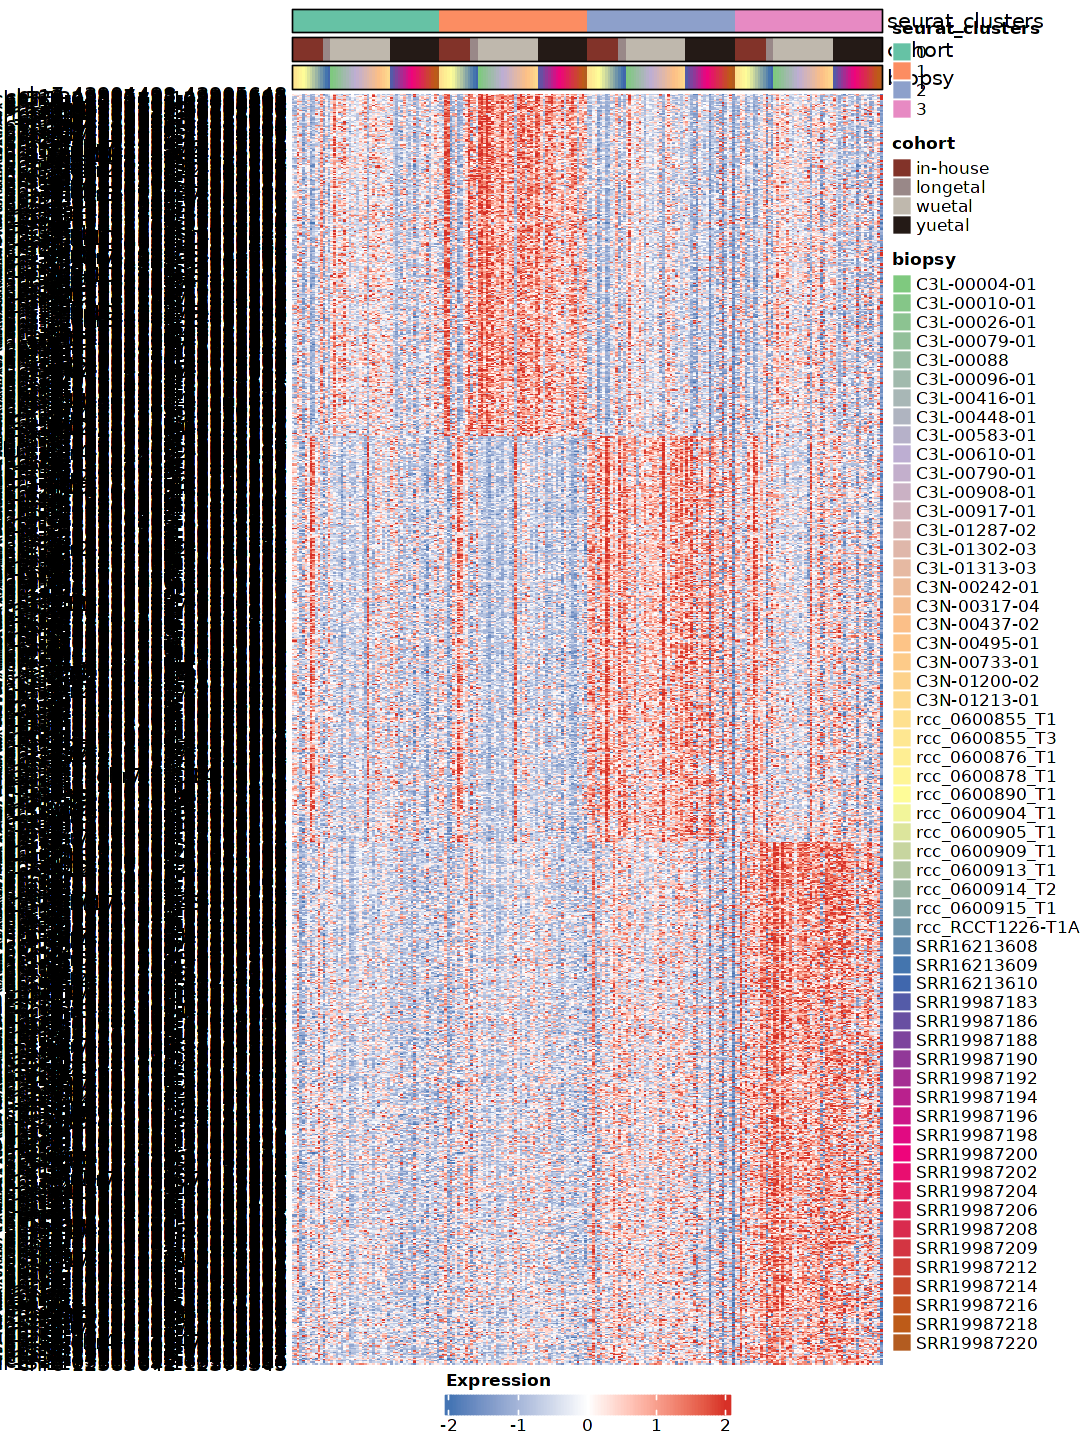

In [25]:
tumor_cols <- colorRampPalette(brewer.pal(4, "Set2"))(4)
cohort_cols <- c("#823329", "#998888", "#BFB8AD", "#241a16")
sample_cols <- colorRampPalette(brewer.pal(10, "Accent"))(65)

options(repr.plot.width = 9, repr.plot.height = 12)
plot_heatmap(sigpeak_obj,
    markers = sigpeaks$peak, anno_var = c("seurat_clusters", "cohort", "biopsy"),
    anno_colors = list(tumor_cols, cohort_cols, sample_cols), sort_var = c("seurat_clusters", "cohort", "biopsy")
)


# Figure 2E: Bar plot of selected pathways enriched in ccRCC peak sets, identified with GREAT


GREAT pathway enrichment results in Supp table 2, sheet E. 

## C1

In [26]:
# Read in GREAT results
great_results <- readRDS('processed_data/C1_GREAT_pathway_results.rds')


In [27]:
# Subset to terms we want to plot for C1
terms <- c("transmembrane transport", "Genes involved in Transport of glucose and other sugars, bile salts and organic acids, metal ions and amine compounds")
selected <- great_results %>% filter(Desc %in% terms)
selected$Desc <- str_wrap(selected$Desc, width = 40)
selected <- selected %>%
  mutate(neg_log10_BinomFdrQ = -log10(BinomFdrQ))


In [28]:
min(selected$GeneFoldEnrich)
max(selected$GeneFoldEnrich)


[1] 2.303926

[1] 5.015452

Color scale limits reflect min and max `GeneFoldEnrich` observed among selected terms for C1, C2, and C3. 

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


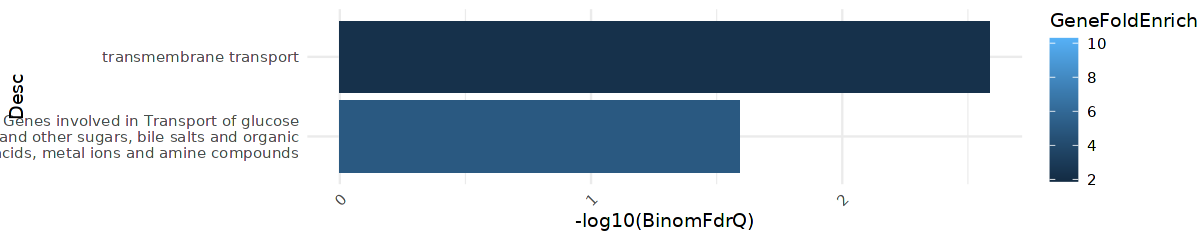

In [29]:
options(repr.plot.width = 10, repr.plot.height = 2)
ggplot(data = selected, aes(x = Desc, y = neg_log10_BinomFdrQ, fill = GeneFoldEnrich)) +
      geom_bar(stat = "identity") +
      theme_minimal() +
      labs(
            y = "-log10(BinomFdrQ)"
      ) +
      coord_flip() +
      scale_fill_gradient(low = "lightblue", high = "blue") +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      scale_fill_gradient(low = "#132B43", high = "#56B1F7", limits = c(1.87, 10.3))


## C2

In [30]:
# Read in GREAT results
great_results <- readRDS('processed_data/C2_GREAT_pathway_results.rds')


In [31]:
# Subset to terms we want to plot for C2
terms <- c("response to wounding", "positive regulation of vascular endothelial growth factor receptor signaling pathway", "vascular disease", "VEGF signaling pathway", "HIF-1-alpha transcription factor network", "negative regulation of cell death")
selected <- great_results %>% filter(Desc %in% terms)
selected$Desc <- str_wrap(selected$Desc, width = 40)
selected <- selected %>%
  mutate(neg_log10_BinomFdrQ = -log10(BinomFdrQ))


In [32]:
min(selected$GeneFoldEnrich)
max(selected$GeneFoldEnrich)


[1] 1.919948

[1] 10.25057

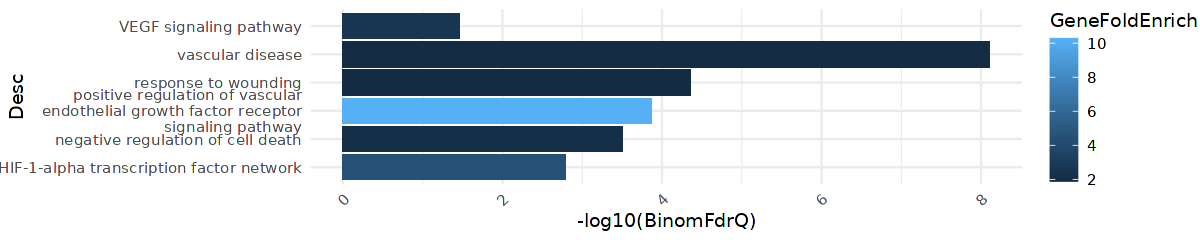

In [33]:
options(repr.plot.width = 10, repr.plot.height = 2)
ggplot(data = selected, aes(x = Desc, y = neg_log10_BinomFdrQ, fill = GeneFoldEnrich)) +
     geom_bar(stat = "identity") +
     theme_minimal() +
     labs(
          y = "-log10(BinomFdrQ)"
     ) +
     coord_flip() +
     theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
     scale_fill_gradient(low = "#132B43", high = "#56B1F7", limits = c(1.87, 10.3))


## C3

In [34]:
# Read in GREAT results
great_results <- readRDS('processed_data/C3_GREAT_pathway_results.rds')


In [35]:
# Subset to terms we want to plot for C3
terms <- c("response to type I interferon", "interferon-gamma-mediated signaling pathway", "regulation of lymphocyte activation", "nephritis", "positive regulation of cytokine production", "Genes involved in Interferon alpha/beta signaling")
selected <- great_results %>% filter(Desc %in% terms)
selected$Desc <- str_wrap(selected$Desc, width = 40)
selected <- selected %>%
  mutate(neg_log10_BinomFdrQ = -log10(BinomFdrQ)) %>%
  arrange(-neg_log10_BinomFdrQ)
selected$Desc <- factor(selected$Desc, levels = rev(selected$Desc))


In [36]:
min(selected$GeneFoldEnrich)
max(selected$GeneFoldEnrich)


[1] 2.038604

[1] 5.234586

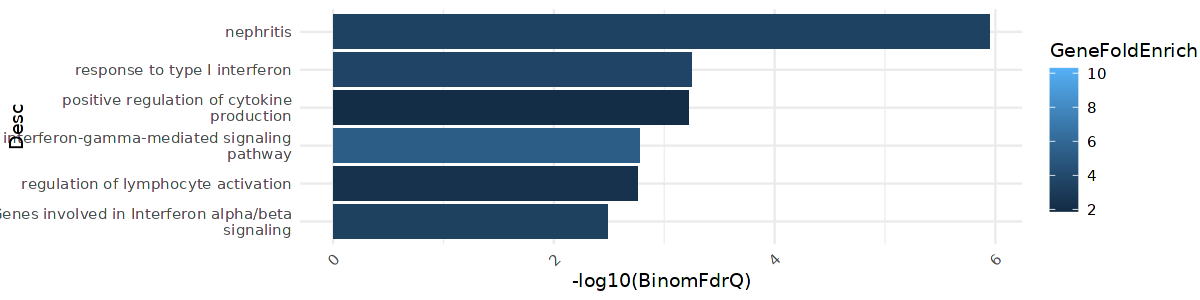

In [37]:
options(repr.plot.width = 10, repr.plot.height = 2.5)
ggplot(data = selected, aes(x = Desc, y = neg_log10_BinomFdrQ, fill = GeneFoldEnrich)) +
      geom_bar(stat = "identity") +
      theme_minimal() +
      labs(
            y = "-log10(BinomFdrQ)"
      ) +
      coord_flip() +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      scale_fill_gradient(low = "#132B43", high = "#56B1F7", limits = c(1.87, 10.3))

# Figure 2F: Heatmap of top 10 TF motif enrichments across ccRCC peak sets

## Enriched TF motif binding sites per ccRCC peak sets

Motif enrichment results in Supp table 2, sheet F. 

In [39]:
sigpeaks$cluster = paste0('C',sigpeaks$cluster)

In [41]:
# Get enriched motif per peak set, c0 had no significant peaks

DefaultAssay(ccrcc) <- "ATAC"
results <- list()
clusters <- c("C1", "C2", "C3")
for (cluster in clusters) {
    cluster_peaks <- sigpeaks %>% filter(cluster == !!cluster)

    # Define a set of background peaks
    ## Find peaks that are open in a significant portion of cells
    percent_to_num_cells <- ceiling(nrow(ccrcc@meta.data) * 0.1)
    open_peaks <- AccessiblePeaks(ccrcc, min.cells = percent_to_num_cells)

    ## Match the overall GC content in the peak set
    meta.feature <- GetAssayData(ccrcc, assay = "ATAC", slot = "meta.features")
    peaks_matched <- MatchRegionStats(
        meta.feature = meta.feature[open_peaks, ],
        query.feature = meta.feature[cluster_peaks$peak, ]
    )

    # Hypergeometric test
    enriched.motifs <- FindMotifs(
        object = ccrcc,
        features = cluster_peaks$peak,
        background = peaks_matched
    )

    # Combine
    enriched.motifs$cluster <- cluster
    results[[cluster]] <- enriched.motifs
}

enriched.motifs.all <- dplyr::bind_rows(results)
saveRDS(enriched.motifs.all, "processed_data/ccRCC_balaned_enriched_motifs.rds")


Matching GC.percent distribution

Testing motif enrichment in 277 regions

Matching GC.percent distribution

Testing motif enrichment in 328 regions

Matching GC.percent distribution

Testing motif enrichment in 422 regions



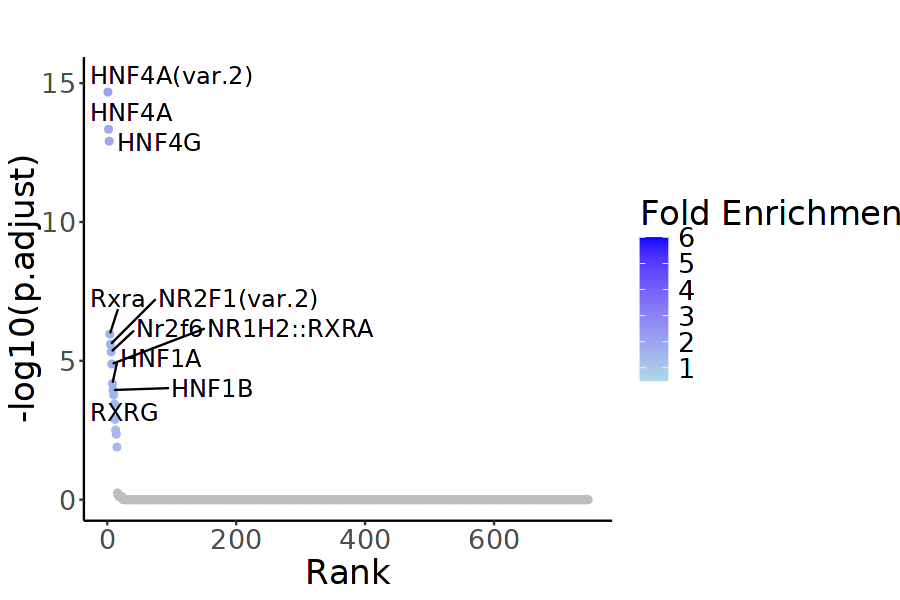

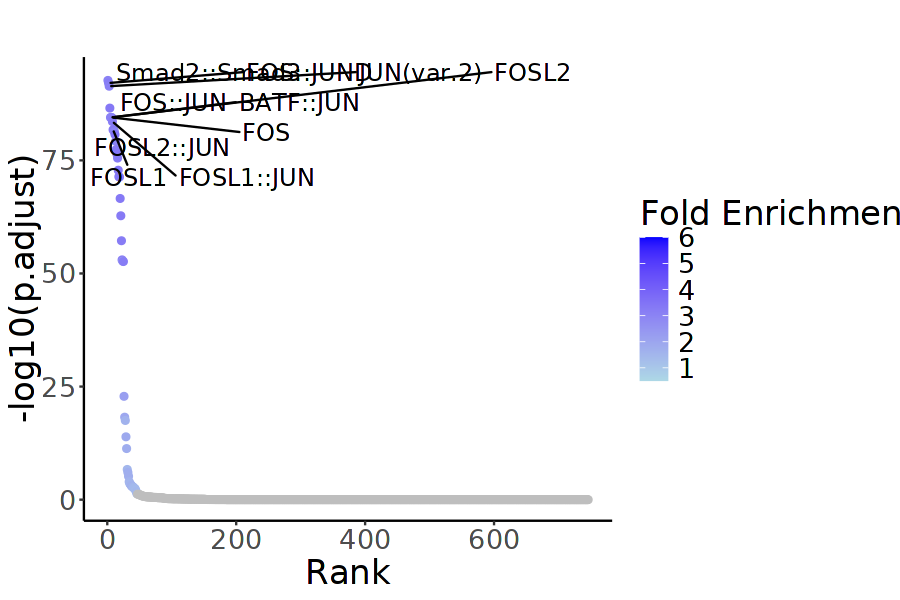

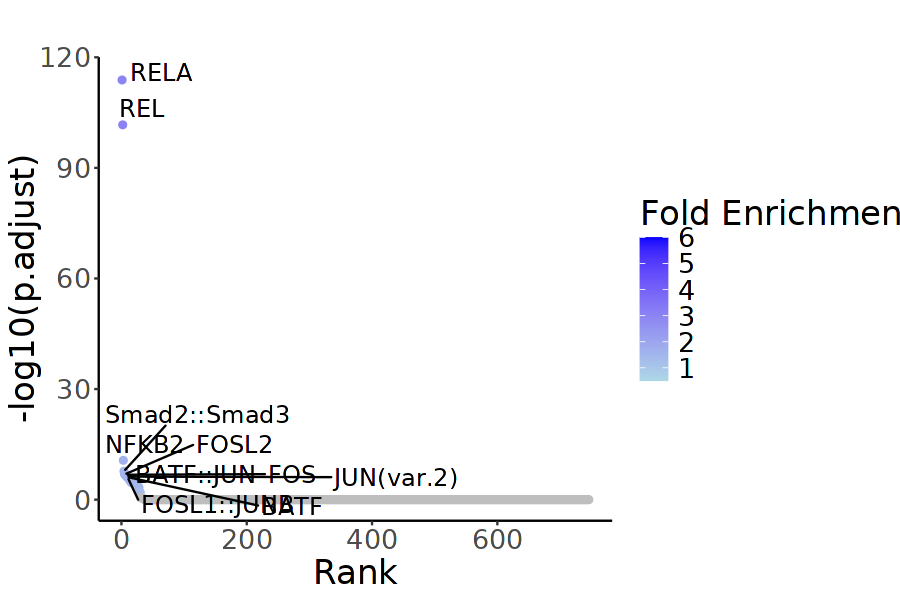

In [42]:
# Visualize top motifs per peak set
options(repr.plot.width = 7.5, repr.plot.height = 5)
create_motif_significance_plot(enriched.motifs.all %>% filter(cluster == "C1"), n_annotate = 10, color_gradient_limits = c(0.5, 6)) + ggtitle("")
create_motif_significance_plot(enriched.motifs.all %>% filter(cluster == "C2"), n_annotate = 10, color_gradient_limits = c(0.5, 6)) + ggtitle("")
create_motif_significance_plot(enriched.motifs.all %>% filter(cluster == "C3"), n_annotate = 10, color_gradient_limits = c(0.5, 6)) + ggtitle("")


Format data for heatmap

In [43]:
# Define a cap for the -log10(p.adjust) transformation
cap_value <- 10 # Adjust this cap value as needed

# Select top 10 TF motifs per cluster
motif_order <- unique((enriched.motifs.all %>% group_by(cluster) %>%
  top_n(n = 10, wt = -p.adjust))$motif.name)

# Transform and cap p-values
df <- enriched.motifs.all %>%
  filter(motif.name %in% motif_order) %>%
  mutate(log_p_adjust = ifelse(p.adjust > 0.05, NA, -log10(p.adjust))) %>%
  mutate(log_p_adjust = ifelse(!is.na(log_p_adjust) & log_p_adjust > cap_value, cap_value, log_p_adjust)) %>%
  # Ensure factor levels are in the order you want
  mutate(
    motif.name = factor(motif.name, levels = rev(motif_order)),
    cluster = factor(cluster, levels = c("C1", "C2", "C3"))
  )

# Add Cluster 0 with all NA values, no results because no peaks
cluster_0 <- data.frame(motif.name = levels(df$motif.name), cluster = factor("C0", levels = c("C0", levels(df$cluster))), log_p_adjust = NA)
df <- dplyr::bind_rows(cluster_0, df)
df <- df %>% mutate(
  motif.name = factor(motif.name, levels = rev(motif_order)),
  cluster = factor(cluster, levels = c("C0", "C1", "C2", "C3"))
)

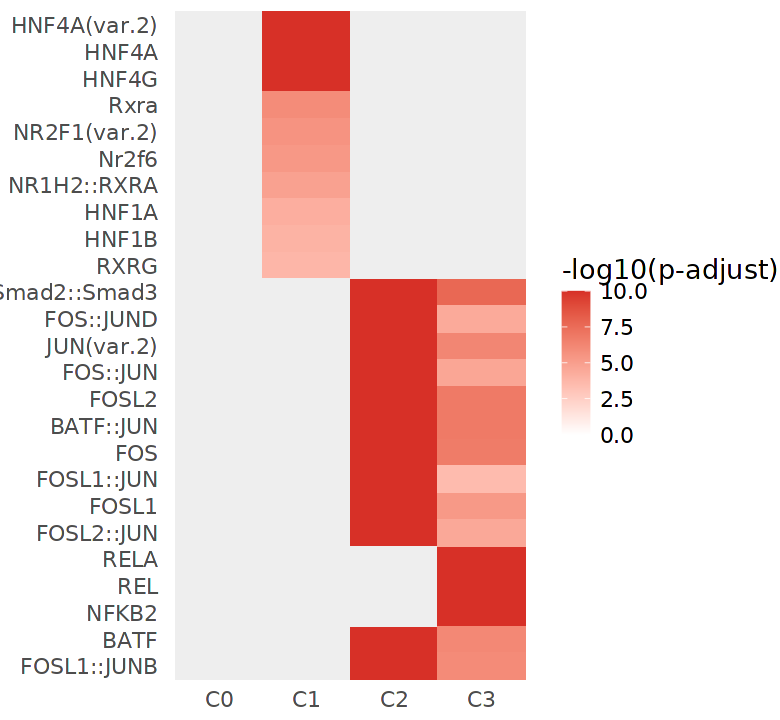

In [44]:
options(repr.plot.width = 6.5, repr.plot.height = 6)
# Create heatmap
ggplot(df, aes(x = cluster, y = motif.name, fill = log_p_adjust)) +
  geom_tile() + # Use geom_tile for heatmap squares
  scale_fill_gradient(low = "white", high = "#d73027", na.value = "#eeeeee", limits = c(0, cap_value)) +
  theme_minimal() +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank(), text = element_text(size = 16)) +
  labs(fill = "-log10(p-adjust)", y = "TF Motif")


# Figure 2G: TF footprinting plots for selected motifs across ccRCC tumor states



In [46]:
# Read in ccRCC balanced object with footprinting information
ccrcc = readRDS('processed_data/ccrcc_balanced_w_footprint_seurat.rds')

In [47]:
ccrcc$annotation <- paste0("C", ccrcc$seurat_clusters)
ccrcc$annotation <- factor(ccrcc$annotation, levels = c("C0", "C1", "C2", "C3"))
Idents(ccrcc) <- "annotation"


C1

Warning message:
"Removed 2052 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


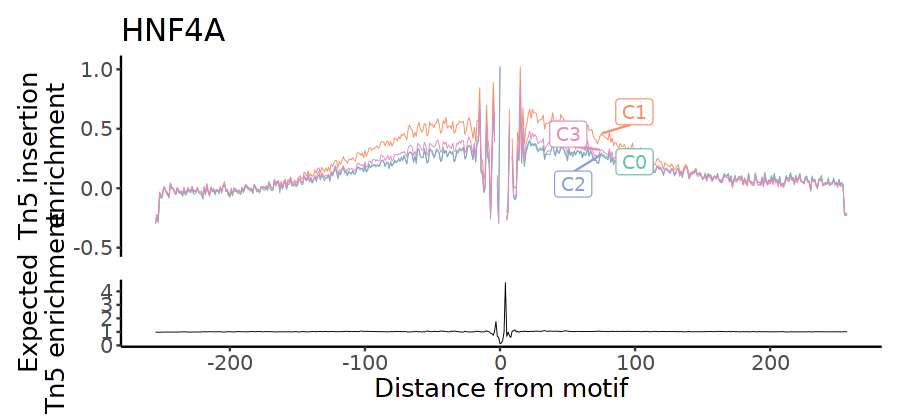

In [48]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
tumor_cols <- colorRampPalette(brewer.pal(4, "Set2"))(4)
p <- PlotFootprint(ccrcc, features = "HNF4A", label.top = 4)
p & scale_color_manual(values = tumor_cols) & theme(text = element_text(size = 15), legend.position = "none")

C2

Warning message:
"Removed 2044 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


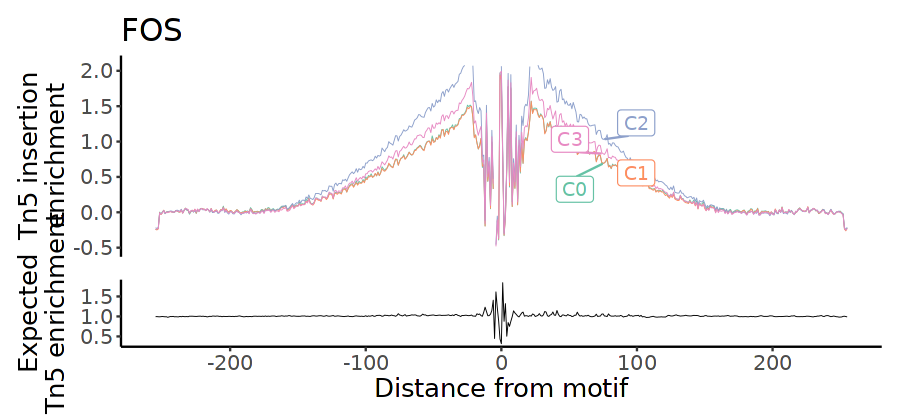

In [49]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
tumor_cols <- colorRampPalette(brewer.pal(4, "Set2"))(4)
p <- PlotFootprint(ccrcc, features = "FOS", label.top = 4)
p & scale_color_manual(values = tumor_cols) & theme(text = element_text(size = 15), legend.position = "none")


C3

Warning message:
"Removed 2040 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


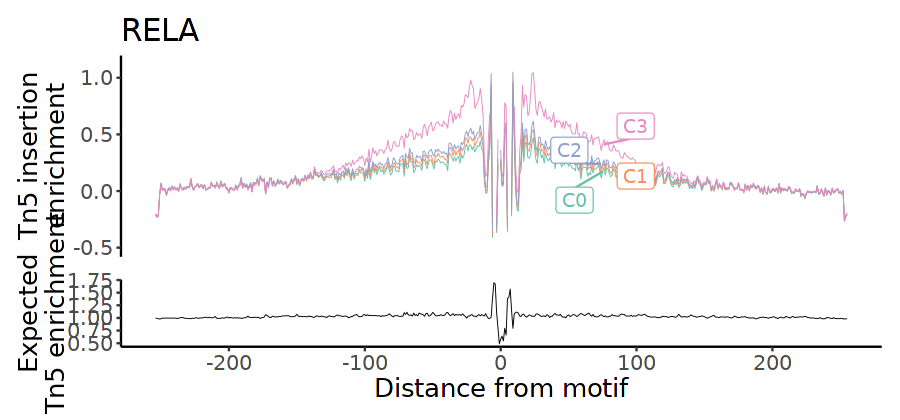

In [50]:
options(repr.plot.width = 7.5, repr.plot.height = 3.5)
tumor_cols <- colorRampPalette(brewer.pal(4, "Set2"))(4)
p <- PlotFootprint(ccrcc, features = "RELA", label.top = 4)
p & scale_color_manual(values = tumor_cols) & theme(text = element_text(size = 15), legend.position = "none")


# Figure 2H: Heatmap of associations between ccRCC tumor programs and epigenetic modifier mutations

Results in supp table 2G

In these plots, we compare the signature score for a given program between tumors with a given mutation to wild type. Including tumors from patients with all disease stages. 

Calculate epigenetic program signature scores

In [51]:
results <- list()
for (cluster in c("C1", "C2", "C3")) {
    peaks <- (sigpeaks %>% filter(cluster == !!cluster))$peak
    sig <- calculate_signature_scores(seurat_object = ccrcc, sig_peak_set = peaks, pct.open = 0.1, final_score_name = glue("{cluster}_signature"))
    results[[cluster]] <- sig
}
signature_df <- dplyr::bind_cols(results)
ccrcc <- AddMetaData(ccrcc, signature_df)


Matching GC.percent distribution

Matching GC.percent distribution

Matching GC.percent distribution



Calculate associations between signature scores and mutations

In [52]:
library(effsize)
summary_stats <- list()

for (gene in c("BAP1", "SETD2", "PBRM1", "KDM5C")) {
  value <- glue("{gene}_LOF")
  metadata <- ccrcc@meta.data %>%
    filter((ccrcc@meta.data[, value] == 1) | (ccrcc@meta.data[, gene] == 0))
  metadata[, gene] <- ifelse(metadata[, gene] == 1, "pLOF", "WT")
  metadata[, gene] <- factor(metadata[, gene], levels = c("pLOF", "WT"))

  for (cluster in c("C1", "C2", "C3")) {
    sig <- glue("{cluster}_signature")

    df <- metadata %>%
      group_by(biopsy, !!sym(gene)) %>%
      summarise(median_sig = median(!!sym(sig)), .groups = "drop")

    wt <- df %>%
      filter(!!sym(gene) == "WT") %>%
      pull(median_sig)
    mt <- df %>%
      filter(!!sym(gene) == "pLOF") %>%
      pull(median_sig)

    cliffs <- tryCatch(cliff.delta(mt, wt)$estimate, error = function(e) NA)
    pval <- wilcox.test(mt, wt)$p.value

    summary_stats[[length(summary_stats) + 1]] <- data.frame(
      gene = gene,
      signature = cluster,
      cliffs_delta = cliffs,
      pval = pval
    )
  }
}

summary_df <- bind_rows(summary_stats)
summary_df$p_adj <- p.adjust(summary_df$pval, method = "fdr")
saveRDS(summary_df, 'processed_data/epimuts_vs_ccrccstates.rds')

In [53]:
summary_df


gene,signature,cliffs_delta,pval,p_adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BAP1,C1,0.14285714,0.5623011815,0.636528233
BAP1,C2,0.57763975,0.0126930512,0.076158307
BAP1,C3,0.77018634,0.0004462218,0.005354661
SETD2,C1,-0.12098765,0.5834842135,0.636528233
SETD2,C2,0.32345679,0.1331067199,0.532426879
SETD2,C3,0.28888889,0.1813800476,0.544140143
PBRM1,C1,-0.14871795,0.4103861847,0.636528233
PBRM1,C2,-0.12820513,0.4790176649,0.636528233
PBRM1,C3,0.03247863,0.8635256593,0.863525659


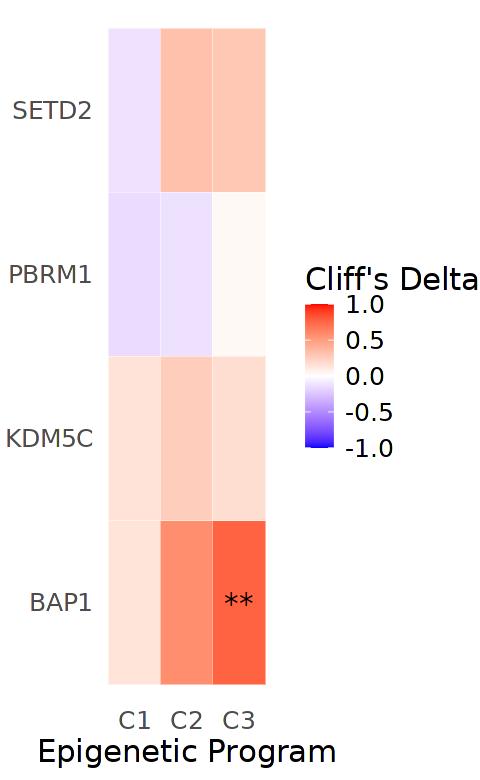

In [54]:
# Add stars for significance
summary_df$star <- case_when(
  summary_df$p_adj < 0.001 ~ "***",
  summary_df$p_adj < 0.01 ~ "**",
  summary_df$p_adj < 0.05 ~ "*",
  TRUE ~ ""
)

options(repr.plot.width = 4, repr.plot.height = 6.5)
ggplot(summary_df, aes(x = signature, y = gene, fill = cliffs_delta)) +
  geom_tile(color = "white") +
  geom_text(aes(label = star), size = 6) +
  scale_fill_gradient2(
    low = "blue", mid = "white", high = "red", midpoint = 0,
    limits = c(-1, 1),
    name = "Cliff's Delta"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.y = element_blank(),
    panel.grid = element_blank(),
    text = element_text(size = 18)
  ) +
  labs(
    x = "Epigenetic Program"
  )


# Figure 2I: Boxplot of per-biopsy median C3 program scores stratified by BAP1 mutation status

Prep data and calculate q-value

In [56]:
# Filter to BAP1 LOF or WT cells only
metadata <- ccrcc@meta.data %>%
  dplyr::filter(BAP1_LOF == 1 | BAP1 == 0) %>%
  dplyr::mutate(
    BAP1 = ifelse(BAP1 == 1, "pLOF", "WT"),
    BAP1 = factor(BAP1, levels = c("pLOF", "WT"))
  )

# Calculate q-value of comparison to show in plot
df <- metadata %>%
  dplyr::group_by(biopsy, BAP1) %>%
  dplyr::summarise(median_sig = median(cluster3_signature), .groups = "drop")

## Extract median signature scores for WT and pLOF groups
wt <- df %>%
  dplyr::filter(BAP1 == "WT") %>%
  dplyr::pull(median_sig)
mt <- df %>%
  dplyr::filter(BAP1 == "pLOF") %>%
  dplyr::pull(median_sig)

## Perform Wilcoxon test and adjust p-value
qval <- p.adjust(wilcox.test(mt, wt)$p.value, n = 12)

## Define y-axis position for annotation
y_scale_range <- max(c(wt, mt)) - min(c(wt, mt))
ypos <- max(c(wt, mt)) + y_scale_range * 0.05


Plot, add q-value

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed"


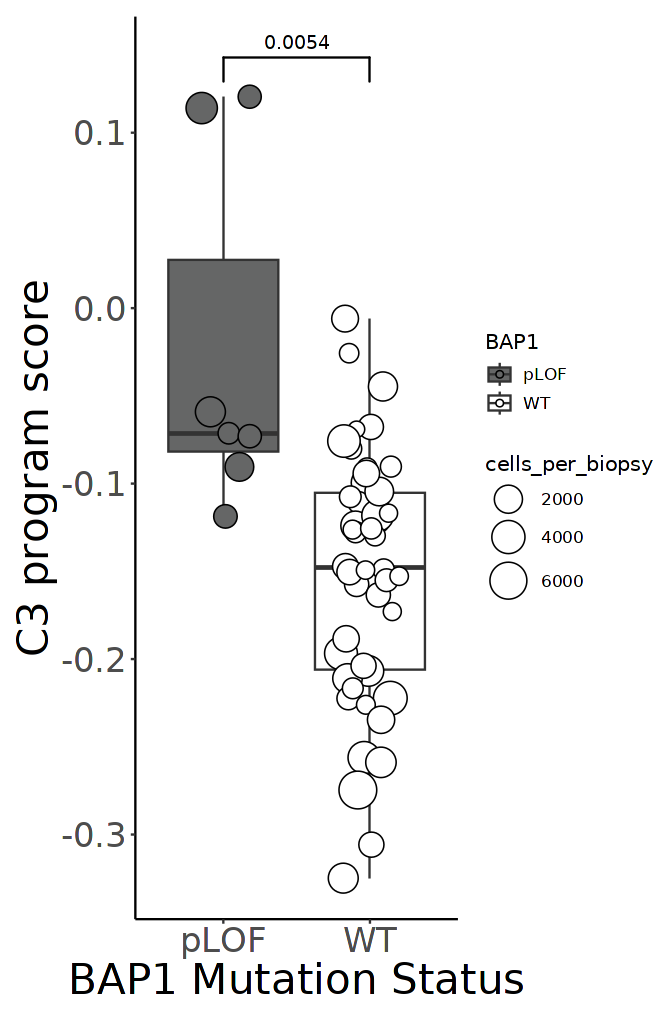

In [57]:
# Plot
options(repr.plot.width = 5.5, repr.plot.height = 8.5)
plot_signature_by_mutation(
  data = metadata,
  mutation_column = "BAP1",
  signature = "cluster3_signature"
) +
  scale_size(range = c(4, 10)) +
  scale_fill_manual(values = c("#656666", "white")) +
  ylab("C3 program score") +
  geom_signif(
    xmin = "pLOF",
    xmax = "WT",
    y_position = ypos,
    annotation = formatC(qval, digits = 2)
  ) + theme(text = element_text(size = 25))


# Figure 2J-K note: These are in the `manuscript-figure2-S2-bulkatac-ccrcctumorstate-survival.ipynb` notebook. 